# **1. Judul Topik : Segmentasi Pelanggan Menggunakan K-Means Clustering**

---

Nama : M. Afif Nuruddin

---

NIM : A11.2022.13954

---

Mata Kuliah : Pembelajaran Mesin

---

Kelompok : A11.4419

# **2. Ringkasan dan Permasalahan**
---
Dalam era digital saat ini, data pelanggan menjadi salah satu aset terpenting bagi perusahaan. Mengelompokkan pelanggan berdasarkan karakteristik tertentu memungkinkan perusahaan untuk melakukan pemasaran yang lebih tepat sasaran dan efisien. Salah satu metode yang digunakan untuk segmentasi pelanggan adalah K-Means Clustering. Metode ini mengelompokkan pelanggan ke dalam segmen-segmen berdasarkan kesamaan karakteristik mereka.

Permasalahan utama yang dihadapi adalah bagaimana mengidentifikasi dan mengelompokkan pelanggan dengan cara yang efisien dan efektif untuk meningkatkan strategi pemasaran dan meningkatkan penjualan.

# **Tujuan Akhir**
---
Tujuan akhir dari proyek segmentasi pelanggan ini adalah:

*   Mengidentifikasi segmen-segmen pelanggan yang berbeda berdasarkan
karakteristik umum mereka.
*   Menentukan strategi pemasaran yang lebih efektif untuk setiap segmen pelanggan.
*   Mengoptimalkan penggunaan sumber daya pemasaran dengan menargetkan kelompok pelanggan yang paling relevan.
*   Meningkatkan kepuasan pelanggan dan loyalitas melalui penawaran yang lebih tepat sasaran.

# **Model atau Alur Penyelesaian**
---

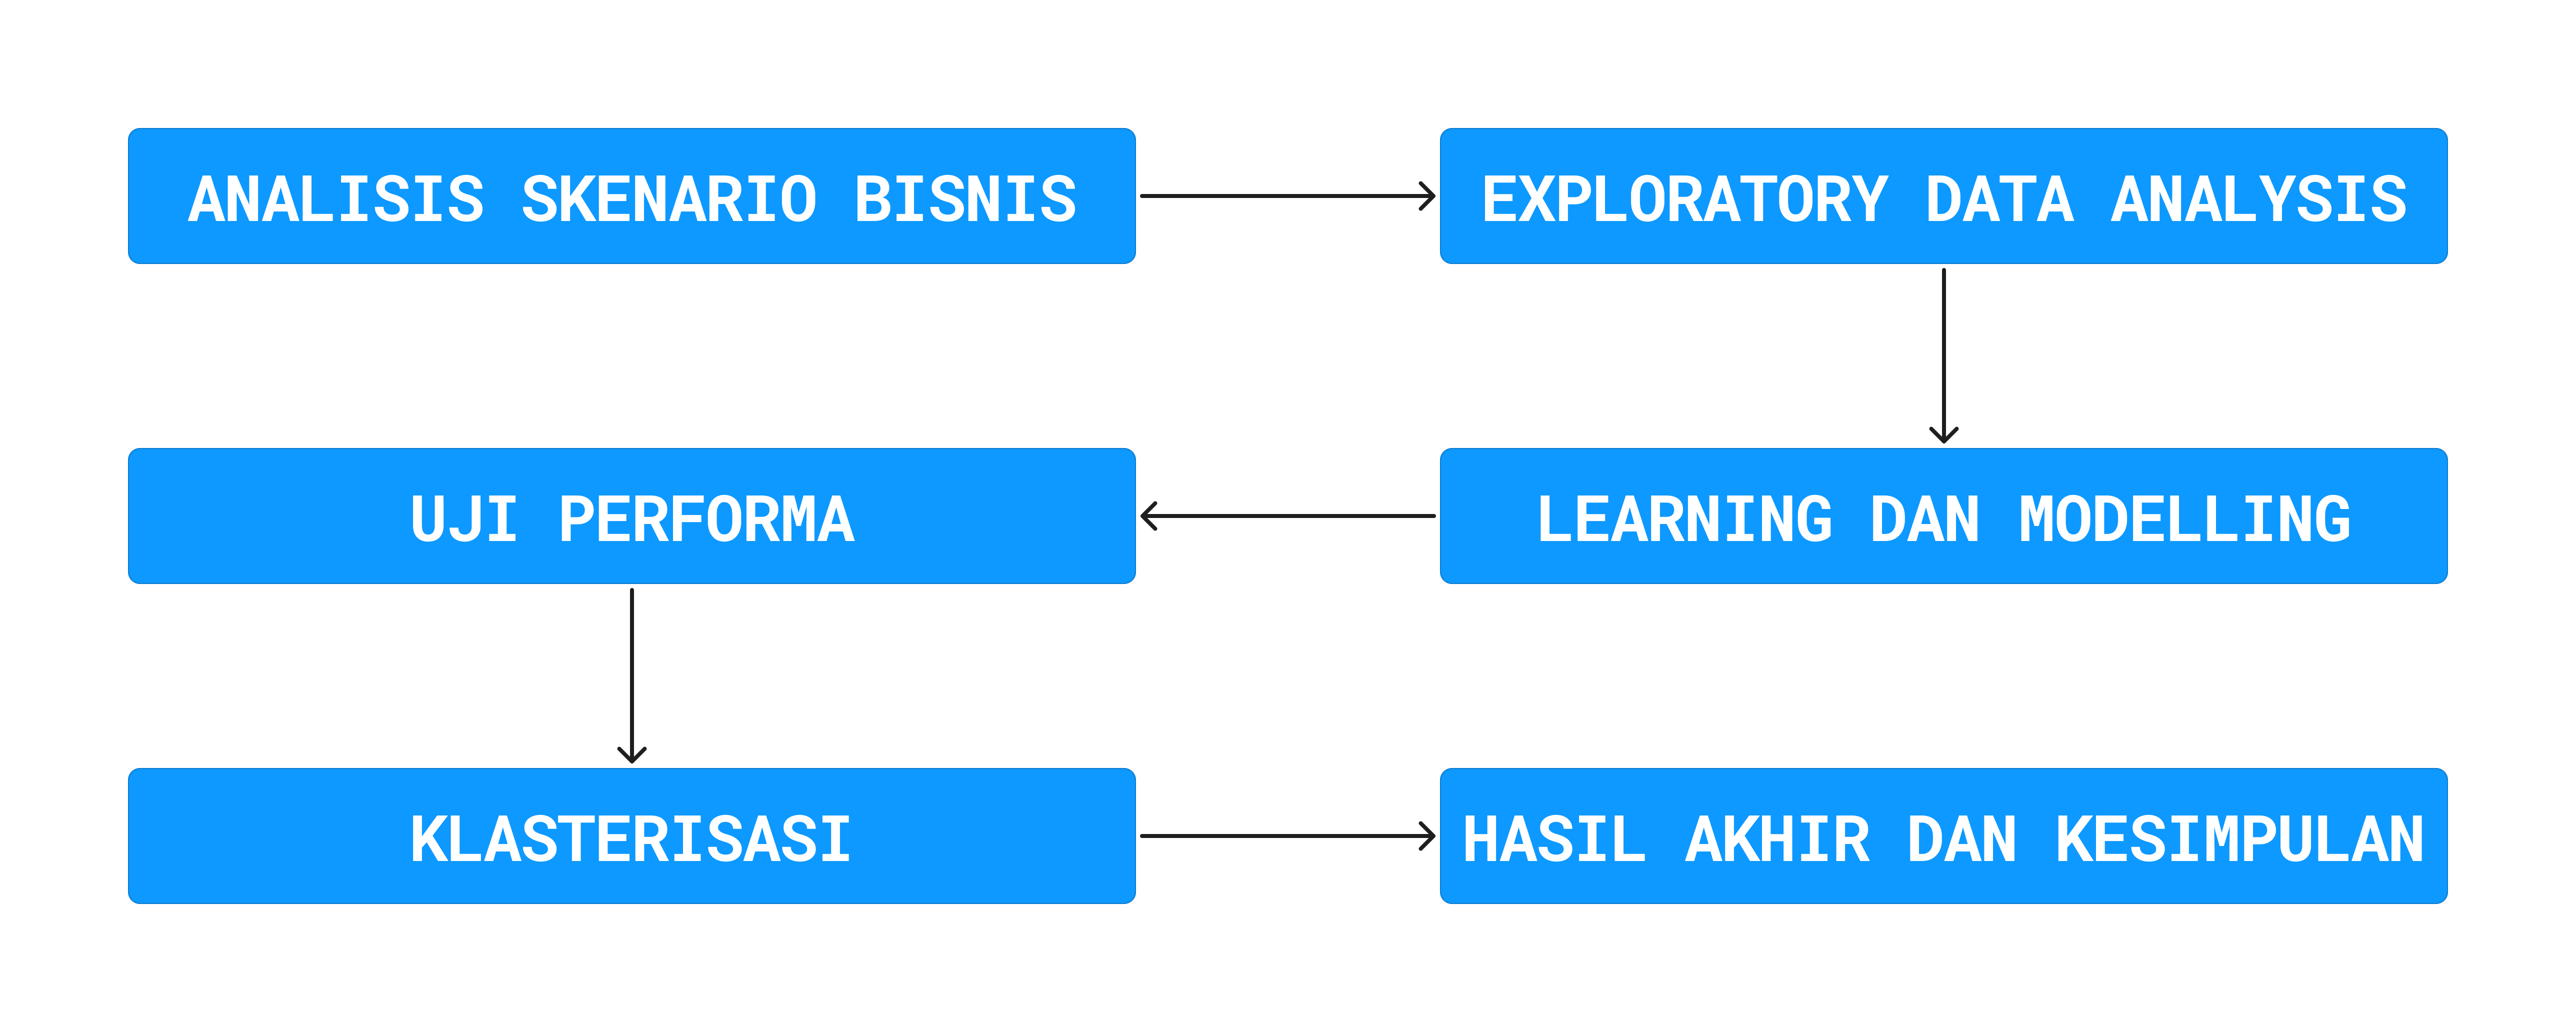

# **3. Penjelasan Dataset**
---
Dalam melakukan pemrosesan data kita perlu memahami dataset yang sedang dan akan kita gunakan, untuk dataset yang digunakan disini adalah dataset segmentation data.csv yang mana di dalam dataset tersebut ada beberapa fitur-fitur yang telah disimbolkan dengan angka, berikut penjelasannya :



*   **ID** : Berfungsi untuk menunjukkan kode unik dari pelanggan.

*   **Sex** : Berfungsi untuk menunjukkan jenis kelamin dari pelanggan, yang dalam data ini hanya ada 2 jenis kelamin yaitu **Laki-laki** yang disimbolkan dengan angka "0", dan **Perempuan** yang disimbolkan dengan angka "1".

*   **Martial Status** : Berfungsi untuk menunjukkan status perkawinan atau pernikahan pelanggan, yang mana pada data ini hanya ada 2 jenis status perkawinan yaitu **Single** yang disimbolkan dengan angka "0", dan **Non-Single (Bercerai / Berpisah / Menikah / Janda)** yang disimbolkan dengan angka "1".

*   **Age** : Berfungsi untuk menunjukkan usia dari tiap-tiap customer yang mana pada data ini ditemukan 2 jenis usia, untuk usia terendah yaitu ada di angka **18 Tahun**, dan usia tertinggi ada di angka **76 Tahun**.

*   **Education** : Berfungsi untuk menunjukkan tingkat pendidikan dari pelanggan yang ada, ada 4 jenis tingkat pendidikan yang ada pada data ini, yang pertama yaitu **Lainnya / Tidak Diketahui** yang disimbolkan dengan angka "0", kemudian ada **Sekolah Menengah Atas** yang disimbolkan dengan angka "1", kemudian ada **Sarjana** yang disimbolkan dengan angka "2", dan terakhir ada **Pasca Sarjana** yang disimbolkan dengan angka "3".

*   **Income** : Berfungsi untuk menunjukkan angka pendapatan dari pelanggan yang ada, yang dalam data ini pendapatan tertinggi (dalam kurs dolar AS) ada di angka **309364**, sedangkan pendapatan terendah ada di angka **35832**.

*   **Occupation** : Berfungsi untuk menunjukkan keterampilan atau pekerjaan dari pelanggan, yang dalam data ini ada 3 jenis keterampilan atau pekerjaan yang dimiliki oleh pelanggan, yang pertama yaitu **Pengangguran / Tidak memiliki Pekerjaan** yang disimbolkan dengan angka "0", kemudian yang kedua ada **Karyawan / Pejabat Terampil** yang disimbolkan dengan angka "1", dan yang terakhir ada  **Manajemen / Wiraswasta / Karyawan Berkualifikasi Tinggi / Pejabat** yang disimbolkan dengan angka "2".

*   **Settlement Size** : Menunjukkan ukuran pemukiman atau kota tempat tinggal pelanggan, yang dalam data ini dibagi menjadi 3 kategori, yaitu yang pertama **Kota Kecil** yang disimbolkan dengan angka "0", kemudian ada **Kota Sedang** yang disimbolkan dengan angka "1", dan terakhir ada **Kota Besar** yang disimbolkan dengan angka "2".


# **Proses EDA dan Features Dataset**

In [27]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Code ini bertujuan untuk menghubungkan Google Colab dengan Google Drive sehingga Anda dapat mengakses file dan folder yang disimpan di Drive langsung dari Colab. Langkah pertama adalah mengimpor modul drive dari google.colab dan kemudian memasang Google Drive ke dalam sistem file Colab dengan drive.mount('/content/drive'). Ini akan meminta otorisasi dari pengguna untuk mengakses Drive mereka. Setelah otorisasi, Google Drive akan tersedia di direktori /content/drive. Selanjutnya, modul sys diimpor dan jalur /content/drive/My Drive/Colab Notebooks/ ditambahkan ke daftar direktori yang dicari Python saat mengimpor modul.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

Code ini bertujuan untuk mempersiapkan lingkungan untuk analisis data, visualisasi, dan pemodelan menggunakan K-Means dan PCA. Pertama, pustaka pandas dan numpy diimpor untuk manipulasi dan analisis data, di mana pandas digunakan untuk bekerja dengan data berbentuk tabel dan numpy digunakan untuk operasi matematika dan array. Selanjutnya, pustaka matplotlib dan seaborn diimpor untuk visualisasi data, dengan seaborn menyediakan pengaturan gaya visualisasi yang lebih mudah dan menarik. Untuk standarisasi data dan pemodelan, StandardScaler dari sklearn.preprocessing diimpor untuk menormalkan data, KMeans dari sklearn.cluster diimpor untuk melakukan clustering, dan PCA dari sklearn.decomposition diimpor untuk reduksi dimensi data.

In [29]:
df =pd.read_csv('/content/drive/My Drive/segmentation data.csv', sep=',')
print("Number of datapoints:", len(df))
df.head()

Number of datapoints: 2000


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


Code ini bertujuan untuk memuat dataset dari Google Drive ke dalam lingkungan Google Colab untuk dianalisis lebih lanjut. Pertama, pustaka pandas digunakan untuk membaca file CSV yang terletak di Google Drive dengan path /content/drive/My Drive/segmentation data.csv. Fungsi pd.read_csv membaca file tersebut dan memuatnya ke dalam variabel data sebagai DataFrame, yang merupakan struktur data seperti tabel yang sangat berguna untuk analisis data. Parameter sep=',' menunjukkan bahwa file CSV dipisahkan oleh koma. Setelah data dimuat, perintah print("Number of datapoints:", len(data)) menampilkan jumlah baris atau datapoints dalam dataset tersebut. Terakhir, data.head() menampilkan lima baris pertama dari DataFrame untuk memberikan gambaran awal tentang struktur dan konten data yang dimuat.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


Code ini bertujuan untuk melihat jumlah atau baris data pada masing-masing kolom yang ada, selain itu juga untuk menampilkan tipe datanya, yang pada dataset ini seluruh tipe datanya sudah bertipe integer.

In [31]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


Code ini bertujuan untuk melihat secara garis besar isi data yang ada pada dataset, dapat kita lihat bahwa rata-rata usia dari pelanggan adalah 35 tahun dan rata-rata penghasilannya adalah 120954 dollar.

In [32]:
df = df.dropna()
print("Jumlah records setelah menghapus records yang mempunyai nilai hilang adalah:", len(df))

Jumlah records setelah menghapus records yang mempunyai nilai hilang adalah: 2000


Code ini bertujuan untuk melakukan drop atau penghapusan terhadap data yang bernilai na atau null, yang mana pada dataset ini tidak ditemukan data yang nilainya na dan null sehingga datanya tetap berjumlah 2000.

Relative Plot Of Some Selected Features: A Data Subset


<Figure size 640x480 with 0 Axes>

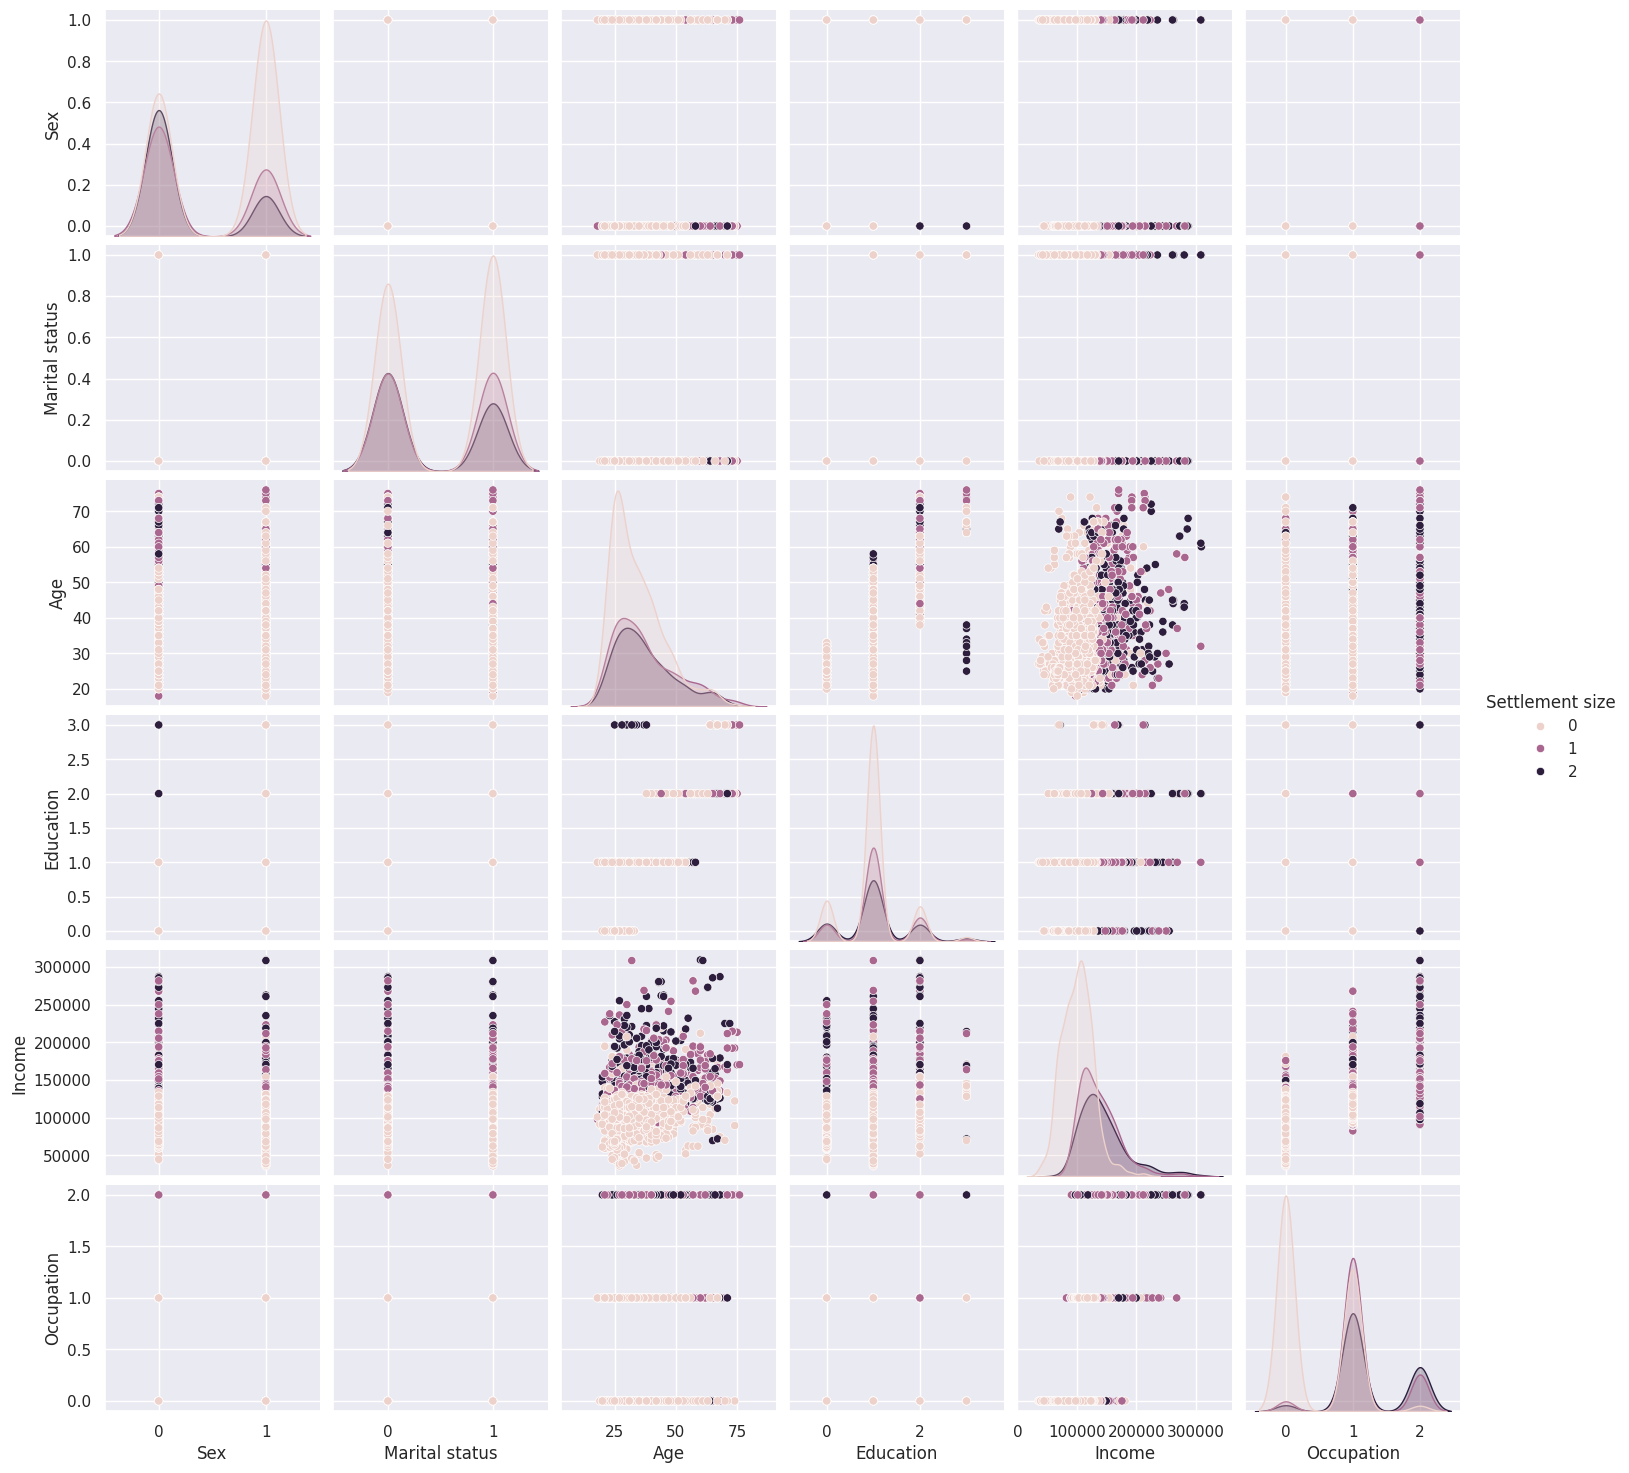

In [33]:
To_Plot = ["Sex", "Marital status", "Age", "Education", "Income", "Occupation", "Settlement size"]

print("Relative Plot Of Some Selected Features: A Data Subset")
plt.figure()

sns.pairplot(df[To_Plot], hue="Settlement size")

plt.show()

Code ini bertujuan untuk membuat visualisasi hubungan antara beberapa fitur yang dipilih dalam dataset menggunakan pustaka seaborn dan matplotlib. Pertama, sebuah daftar bernama To_Plot dibuat yang berisi nama-nama fitur yang akan divisualisasikan: "Sex", "Marital status", "Age", "Education", "Income", "Occupation", dan "Settlement size". Kemudian, perintah print digunakan untuk menampilkan pesan bahwa grafik relatif dari beberapa fitur yang dipilih akan ditampilkan.

Dengan plt.figure(), sebuah figur baru untuk plot dibuat, meskipun ini sebenarnya tidak diperlukan saat menggunakan sns.pairplot karena pairplot akan mengatur figur sendiri. Fungsi sns.pairplot(data[To_Plot], hue="Settlement size") digunakan untuk membuat plot pasangan (pair plot) yang menunjukkan hubungan antara setiap pasangan fitur dalam daftar To_Plot, dengan warna (hue) yang dibedakan berdasarkan fitur "Settlement size". Plot ini membantu untuk melihat hubungan dan pola antara berbagai fitur serta bagaimana mereka berbeda berdasarkan ukuran pemukiman.

Akhirnya, plt.show() digunakan untuk menampilkan plot yang telah dibuat.

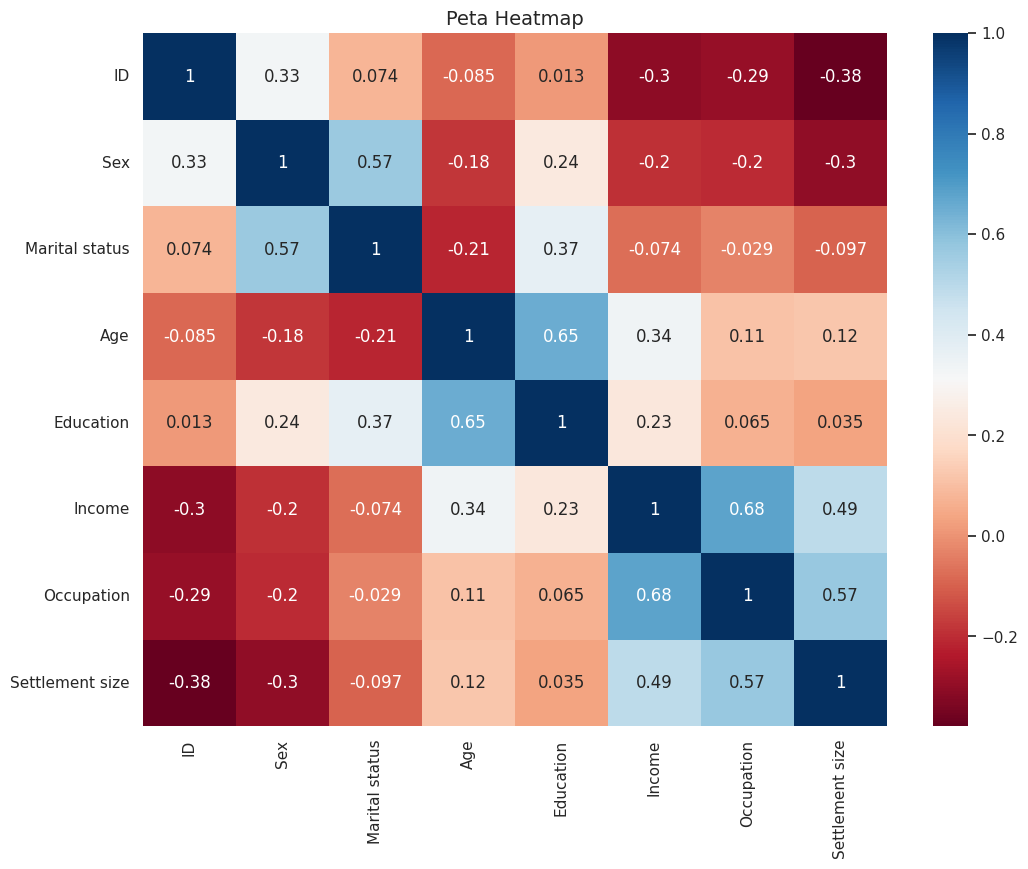

In [34]:
plt.figure(figsize=(12,9))
sns.heatmap( df.corr() ,annot=True,cmap='RdBu')
plt.title('Peta Heatmap',fontsize=14)
plt.yticks(rotation =0)
plt.show()

Setelah menganalisis peta korelasi (heatmap), kita mengidentifikasi adanya korelasi yang kuat antara beberapa fitur dalam dataset. Misalnya, terdapat korelasi yang signifikan antara tingkat pendidikan dan usia, menunjukkan bahwa orang yang lebih tua cenderung memiliki tingkat pendidikan yang lebih tinggi. Selain itu, hubungan antara pendapatan dan pekerjaan juga menarik perhatian, dengan korelasi sebesar 0,68. Ini menunjukkan bahwa orang dengan pendapatan lebih tinggi kemungkinan besar memiliki posisi pekerjaan yang lebih tinggi, seperti manajer.

In [35]:
scaler = StandardScaler()
df_std = scaler.fit_transform(df)

Code ini bertujuan untuk menggunakan objek StandardScaler dari pustaka sklearn.preprocessing untuk melakukan standardisasi data. Standardisasi adalah proses mengubah skala fitur sehingga mereka memiliki nilai rata-rata 0 dan standar deviasi 1. Pertama, scaler = StandardScaler() membuat instance dari StandardScaler. Kemudian, scaler.fit_transform(data) digunakan untuk menyesuaikan (fit) scaler dengan data  dan langsung mengubah (transform) data tersebut. Hasilnya, df_std adalah versi terstandardisasi dari data, di mana setiap fitur telah dinormalkan.

In [36]:
df_std = pd.DataFrame(data = df_std,columns = df.columns)

Code ini bertujuan untuk mengubah data yang telah dinormalisasi menjadi sebuah DataFrame pandas untuk memudahkan analisis dan manipulasi lebih lanjut. Pertama, variabel data_std berisi data yang telah dinormalisasi menggunakan StandardScaler. Dengan menjalankan df_std = pd.DataFrame(data=data_std, columns=data.columns), kita membuat DataFrame baru df_std menggunakan data_std, dan memberikan nama kolom yang sama seperti pada DataFrame asli data. Ini memastikan bahwa struktur dan nama kolom tetap konsisten dengan data asli, memudahkan referensi dan pemahaman data saat melakukan analisis lebih lanjut. Hal ini juga memungkinkan penggunaan berbagai fungsi pandas untuk memanipulasi dan menganalisis data terstandardisasi dengan lebih efisien.

# **4. Proses Learning atau Modelling**

In [37]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df_std)
    wcss.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Code ini bertujuan untuk menghitung nilai Within-Cluster Sum of Squares (WCSS) untuk berbagai jumlah cluster yang berbeda dalam analisis K-Means Clustering. Pertama, sebuah list kosong wcss dibuat untuk menyimpan nilai WCSS dari setiap iterasi. Dalam loop for, iterasi dilakukan dari 1 hingga 10, yang mewakili jumlah cluster yang akan diuji. Pada setiap iterasi, objek KMeans dibuat dengan n_clusters = i untuk menguji jumlah cluster tersebut. Parameter init='k-means++' menunjukkan penggunaan metode inisialisasi k-means++ untuk menentukan posisi awal centroid secara cerdas, dan random_state = 42 digunakan untuk memastikan hasil yang konsisten dalam setiap eksekusi.

Setelah model KMeans ditentukan dengan memanggil kmeans.fit(data_std), nilai WCSS dari model tersebut dihitung dan disimpan dalam wcss menggunakan kmeans.inertia_. Nilai WCSS adalah ukuran penyebaran data di dalam cluster-cluster yang dihasilkan oleh K-Means. Semakin kecil nilai WCSS, semakin kompak cluster-clusternya, yang menunjukkan bahwa pengelompokan data menjadi cluster-cluster tersebut cukup baik.

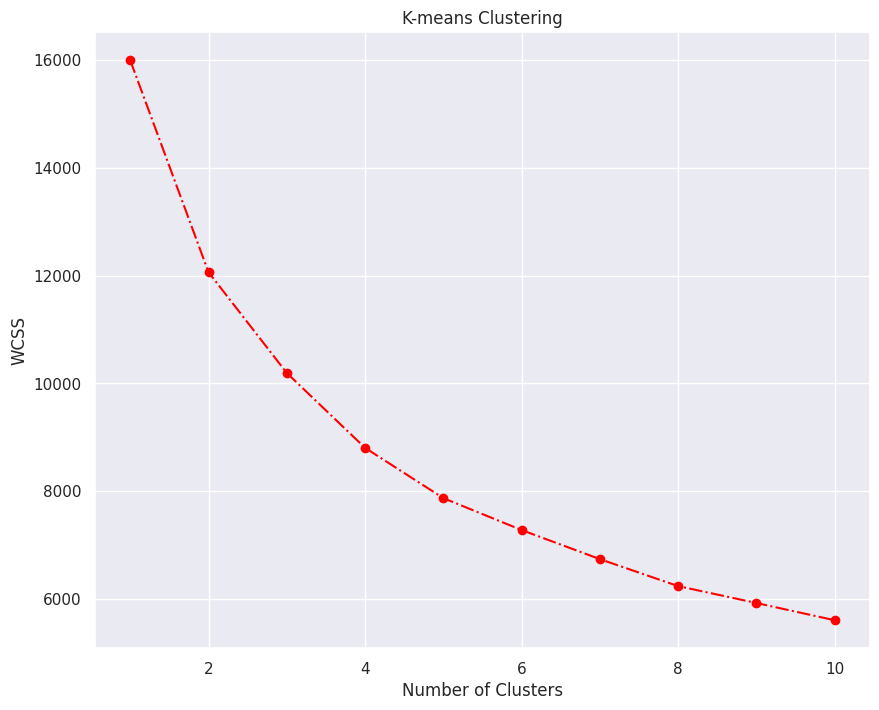

In [38]:
plt.figure(figsize = (10,8))
plt.plot(range(1, 11), wcss, marker = 'o', linestyle = '-.',color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')
plt.show()

Plot tersebut menunjukkan adanya penurunan tajam dari nilai 0 sampai 4 kemudian melandai dari 5 sampai 10, hal ini menunjukkan tanda-tanda bahwa ada 4 cluster pada dataset yang kita gunakan.

In [39]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)

Pada bagian ini kita kelompokkan cluster menjadi 4 kelompok.

In [40]:
kmeans.fit(df_std)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=4, random_state=42)

In [41]:
df_segm_kmeans= df_std.copy()
df_std["Segment K-means"] = kmeans.labels_
df_std.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segment K-means
0,-1.731185,-0.917399,-0.993024,2.653614,1.604323,0.097524,0.296823,1.552326,3
1,-1.729453,1.090038,1.007025,-1.187132,-0.063372,0.782654,0.296823,1.552326,0
2,-1.727721,-0.917399,-0.993024,1.117316,-0.063372,-0.833202,-1.269525,-0.909730,2
3,-1.725989,-0.917399,-0.993024,0.775916,-0.063372,1.328386,0.296823,0.321298,1
4,-1.724257,-0.917399,-0.993024,1.458716,-0.063372,0.736932,0.296823,0.321298,1


Code ini bertujuan untuk menambahkan hasil clustering K-Means ke dalam DataFrame df_segm_kmeans. Pertama, data yang telah dinormalisasi disalin ke dalam DataFrame baru df_segm_kmeans. Selanjutnya, kolom baru dengan nama "Segment K-means" ditambahkan ke DataFrame ini, yang berisi label segmen hasil dari proses clustering K-Means. Setiap baris dalam DataFrame sekarang memiliki nilai-nilai fitur yang telah dinormalisasi serta label segmen yang menunjukkan cluster mana yang paling sesuai untuk data tersebut berdasarkan analisis clustering. Hasil dari df_segm_kmeans.head() menampilkan lima baris pertama dari DataFrame yang telah diperbarui, menunjukkan struktur data setelah ditambahkan label segmen dari K-Means Clustering.

# **5. Uji Performa Model**

In [42]:
features = ["Sex", "Marital status", "Age", "Education", "Income", "Occupation", "Settlement size"]
X = df[features]

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
kmeans.fit(X_std)

cluster_labels = kmeans.labels_
df['Cluster'] = cluster_labels

# Evaluasi performa clustering menggunakan Silhouette Score
silhouette_avg = silhouette_score(X_std, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score: 0.26879180394522123


Code ini menunjukkan evaluasi performa clustering menggunakan metode **Silhouette Score**, Silhouette Score adalah metrik evaluasi yang digunakan untuk mengukur seberapa baik setiap titik data berada dalam cluster-nya sendiri dibandingkan dengan cluster lainnya. Nilai Silhouette Score berkisar antara -1 hingga 1:

Nilai dekat dengan +1 menunjukkan bahwa titik data berada dalam cluster yang tepat.
Nilai dekat dengan 0 menunjukkan bahwa titik data berada di dekat batas antara dua cluster.
Nilai dekat dengan -1 menunjukkan bahwa titik data mungkin ditempatkan di cluster yang salah.

Dalam pengujian ini hasil nilai Silhouette Score yaitu **0.26879180394522123**, ini menunjukkan bahwa pengelompokan data menggunakan model K-Means memiliki hasil yang cukup baik. Nilai positif menunjukkan bahwa sebagian besar titik data ditempatkan di dalam cluster yang sesuai dengan karakteristiknya sendiri, meskipun ada beberapa titik yang mungkin berada dekat dengan batas antara cluster. Interpretasi ini menandakan bahwa penggunaan model K-Means dengan jumlah cluster yang dipilih memberikan hasil yang cukup baik dalam memisahkan data ke dalam kelompok yang berbeda.

In [43]:
df_segm_analisis = df_std.groupby(['Segment K-means']).mean()
df_segm_analisis

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Segment K-means,,,,,,,,
0,0.216385,0.841696,1.004079,-0.589431,0.049608,-0.403075,-0.282195,-0.394837
1,-0.593534,-0.857049,-0.635421,-0.023564,-0.501406,0.498439,0.688410,0.798516
2,0.697055,-0.107716,-0.907103,-0.104064,-0.493232,-0.696787,-0.869527,-0.836279
3,-0.236585,0.056580,0.369972,1.698960,1.814329,0.928253,0.447657,0.421604


#**Penjelasan Hasil Akhir Cluster dan Personalisasi Cluster**
---
Data yang diberikan dan ditampilkan pada **df_segm_analisis** adalah data yang telah distandarisasi dalam bentuk **Z-Score**.

### **Apa itu Z-Score?**
---
Z-score, atau standar skor, mengukur seberapa jauh nilai data dari rata-rata populasi dalam satuan standar deviasi. Rumusnya adalah:

𝑍 = ( 𝑋 − 𝜇 ) / 𝜎

di mana:

𝑋 adalah nilai data yang akan dihitung z-scorenya.

𝜇 adalah rata-rata dari data.

𝜎 adalah standar deviasi dari data.
### **Interpretasi Z-Score**
---
*   Z-score = 0: Nilai data sama dengan rata-rata.
*   Z-score positif (> 0): Nilai data berada di atas rata-rata.
*   Z-score > 1: Nilai data jauh di atas rata-rata.
*   Z-score negatif (< 0): Nilai data berada di bawah rata-rata.
*   Z-score < -1: Nilai data jauh di bawah rata-rata.

### **Hasil Baca Z-Score dari Hasil Klustering**
---
**1.   Kluster 0**

**Sex (0.841696):** Pelanggan laki-laki lebih dominan.

**Marital status (1.004079):** Banyak pelanggan yang sudah menikah atau non-single.

**Age (-0.589431):** Usia pelanggan sedikit lebih muda dari rata-rata.

**Education (0.049608):** Tingkat pendidikan mendekati rata-rata.

**Income (-0.403075):** Pendapatan sedikit di bawah rata-rata.

**Occupation (-0.282195):** Lebih banyak pelanggan yang memiliki pekerjaan kurang terampil atau tidak memiliki pekerjaan.

**Settlement size (-0.394837):** Pelanggan cenderung tinggal di kota kecil atau sedang.


**2.   Kluster 1**

**Sex (-0.857049):** Lebih banyak pelanggan perempuan.

**Marital status (-0.635421):** Sebagian besar pelanggan single.

**Age (-0.023564):** Usia pelanggan mendekati rata-rata.

**Education (-0.501406):** Tingkat pendidikan sedikit di bawah rata-rata.

**Income (0.498439):** Pendapatan di atas rata-rata.

**Occupation (0.688410):** Sebagian besar pelanggan bekerja sebagai karyawan terampil.

**Settlement size (0.798516):** Pelanggan cenderung tinggal di kota besar.

**3.   Kluster 2**

**Sex (-0.107716):** Jenis kelamin pelanggan mendekati rata-rata, sedikit lebih banyak perempuan.

**Marital status (-0.907103):** Banyak pelanggan yang single.

**Age (-0.104064):** Usia pelanggan mendekati rata-rata.

**Education (-0.493232):** Tingkat pendidikan sedikit di bawah rata-rata.

**Income (-0.696787):** Pendapatan di bawah rata-rata.

**Occupation (-0.869527):** Lebih banyak pelanggan yang tidak memiliki pekerjaan atau pekerjaan kurang terampil.

**Settlement size (-0.836279):** Pelanggan cenderung tinggal di kota kecil.

**4.   Kluster 3**

**Sex (0.056580):** Jenis kelamin pelanggan mendekati rata-rata, sedikit lebih banyak laki-laki.

**Marital status (0.369972):** Banyak pelanggan yang sudah menikah atau non-single.

**Age (1.698960):** Usia pelanggan jauh lebih tua dari rata-rata.

**Education (1.814329):** Tingkat pendidikan jauh di atas rata-rata.

**Income (0.928253):** Pendapatan jauh di atas rata-rata.

**Occupation (0.447657):** Banyak pelanggan yang bekerja di manajemen atau pekerjaan berkualifikasi tinggi.

**Settlement size (0.421604):** Pelanggan cenderung tinggal di kota sedang atau besar.

### **Kesimpulan**
---
**Kluster 0:** Lebih banyak pelanggan laki-laki yang sudah menikah, usia lebih muda, dengan pendapatan sedikit di bawah rata-rata, dan cenderung tinggal di kota kecil atau sedang.

**Kluster 1:** Lebih banyak pelanggan perempuan yang single, dengan pendapatan di atas rata-rata, bekerja sebagai karyawan terampil, dan tinggal di kota besar.

**Kluster 2:** Jenis kelamin mendekati rata-rata, banyak yang single, pendapatan di bawah rata-rata, dan lebih banyak yang tidak memiliki pekerjaan atau pekerjaan kurang terampil, tinggal di kota kecil.

**Kluster 3:** Jenis kelamin mendekati rata-rata, lebih banyak yang sudah menikah, usia jauh lebih tua, pendidikan dan pendapatan jauh di atas rata-rata, bekerja di manajemen atau pekerjaan berkualifikasi tinggi, dan tinggal di kota sedang atau besar.



# **6. Penjelasan Hasil Akhir dan Kesimpulan**
---
Dari hasil kluster berikut adalah strategi pemasaran yang disarankan untuk setiap segmen pelanggan :

---
**1. Menentukan Strategi Pemasaran yang Lebih Efektif untuk Setiap Segmen Pelanggan**

**Kluster 0**

Karakteristik: Lebih banyak pelanggan laki-laki yang sudah menikah, usia lebih muda, dengan pendapatan sedikit di bawah rata-rata, dan cenderung tinggal di kota kecil atau sedang.

Strategi Pemasaran

Produk dan Layanan: Fokus pada produk yang relevan untuk keluarga muda dan kebutuhan rumah tangga.

Promosi: Penawaran diskon keluarga, bundling produk untuk kebutuhan rumah tangga.

Media: Gunakan media sosial dan platform lokal yang populer di kota kecil dan sedang.

**Kluster 1**

Karakteristik: Lebih banyak pelanggan perempuan yang single, dengan pendapatan di atas rata-rata, bekerja sebagai karyawan terampil, dan tinggal di kota besar.

Strategi Pemasaran

Produk dan Layanan: Produk premium dan layanan yang mendukung gaya hidup urban.

Promosi: Program loyalitas, penawaran eksklusif untuk produk baru, acara eksklusif.

Media: Gunakan media sosial yang populer di kota besar, influencer marketing, dan iklan digital.

**Kluster 2**

Karakteristik: Jenis kelamin mendekati rata-rata, banyak yang single, pendapatan di bawah rata-rata, lebih banyak yang tidak memiliki pekerjaan atau pekerjaan kurang terampil, tinggal di kota kecil.

Strategi Pemasaran

Produk dan Layanan: Produk dengan harga terjangkau, kebutuhan dasar dan esensial.

Promosi: Penawaran diskon besar, program cicilan tanpa bunga.

Media: Gunakan media lokal dan platform yang populer di kota kecil, flyer dan brosur di area lokal.

**Kluster 3**

Karakteristik: Jenis kelamin mendekati rata-rata, lebih banyak yang sudah menikah, usia jauh lebih tua, pendidikan dan pendapatan jauh di atas rata-rata, bekerja di manajemen atau pekerjaan berkualifikasi tinggi, dan tinggal di kota sedang atau besar.

Strategi Pemasaran

Produk dan Layanan: Produk premium, layanan eksklusif, investasi dan produk keuangan.

Promosi: Penawaran VIP, program penghargaan pelanggan setia, seminar dan acara eksklusif.

Media: Gunakan media bisnis dan keuangan, iklan di platform profesional seperti LinkedIn.

---
**2. Mengoptimalkan Penggunaan Sumber Daya Pemasaran dengan Menargetkan Kelompok Pelanggan yang Paling Relevan**

Fokus pada Kluster dengan Potensi Tinggi: Kluster 1 dan Kluster 3 memiliki pendapatan di atas rata-rata dan cenderung tinggal di kota besar atau sedang. Fokuskan lebih banyak sumber daya pemasaran untuk menjangkau kluster ini dengan produk dan layanan premium.

Efisiensi Biaya untuk Kluster dengan Anggaran Terbatas: Kluster 2 memiliki pendapatan di bawah rata-rata. Optimalkan kampanye pemasaran dengan menekankan penawaran yang hemat biaya dan relevan dengan kebutuhan dasar mereka.

---
**3. Meningkatkan Kepuasan Pelanggan dan Loyalitas melalui Penawaran yang Lebih Tepat Sasaran**

Personalisasi Penawaran: Gunakan data dari klustering untuk membuat penawaran yang dipersonalisasi sesuai dengan karakteristik masing-masing kluster. Misalnya, kluster 3 dapat ditargetkan dengan penawaran investasi dan produk keuangan yang disesuaikan dengan usia dan pendapatan mereka.

Program Loyalitas dan Penghargaan: Kembangkan program loyalitas yang berbeda untuk setiap kluster. Kluster 1 dan Kluster 3 dapat diberikan akses ke acara eksklusif dan penawaran VIP, sementara kluster 0 dan Kluster 2 dapat diberikan poin belanja dan diskon khusus.

Feedback dan Engagement: Selalu minta umpan balik dari pelanggan dalam setiap kluster untuk memahami kebutuhan dan preferensi mereka lebih baik. Gunakan umpan balik ini untuk meningkatkan produk dan layanan.